In [14]:
import pandas as pd
from imblearn.pipeline import make_pipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from sklearn.model_selection import train_test_split, cross_validate

In [61]:
from sklearn.metrics import (
    recall_score, precision_score, f1_score, accuracy_score,
    roc_auc_score, matthews_corrcoef, brier_score_loss, log_loss,
    balanced_accuracy_score
)

scoring = {
    'Recall': 'recall',
    'Precision': 'precision',
    'F1': 'f1',
    'Accuracy': 'accuracy',
    'ROC AUC': 'roc_auc',
    'Brier': 'neg_brier_score',
    'LogLoss': 'neg_log_loss',
    'BalancedAccuracy': 'balanced_accuracy'
}

def evaluate_model(model, X_test, y_test):
    # Get predictions and probabilities
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    
    # For binary classification, use positive class probabilities
    if y_proba.shape[1] == 2:
        y_proba_pos = y_proba[:, 1]
    else:
        y_proba_pos = y_proba
    
    return {
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba_pos),
        "MCC": matthews_corrcoef(y_test, y_pred),
        "Brier": brier_score_loss(y_test, y_proba_pos),
        "LogLoss": log_loss(y_test, y_proba),
        "BalancedAccuracy": balanced_accuracy_score(y_test, y_pred)
    }

def print_metrics(metrics: dict):
    # Print formatted results
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

def print_results(results: dict, scoring: dict = scoring):
    # Print formatted results
    for metric in scoring.keys():
        print(f"{metric}: {abs(results[f'test_{metric}'].mean()):.4f}")

In [3]:
data = pd.read_parquet("../data/RLCS23_shots.parquet")
X = data.drop(columns="outcome")
y = data["outcome"] == "goal"
y.rename("is_goal", inplace=True)
y.head(100)

0     False
1     False
2     False
3     False
4     False
      ...  
16    False
17    False
18    False
19    False
20    False
Name: is_goal, Length: 100, dtype: bool

In [4]:
X.head(100)

,goal_angle,ball_height,ball_distance
0,0.346381,92.440002,5108.253373
1,0.140959,576.109985,4169.977987
2,0.400684,621.380005,4376.777363
3,0.321021,280.329987,3851.686629
4,0.376511,1108.589966,4714.106861
...,...,...,...
16,0.530497,1008.320007,3353.969064
17,0.575091,200.919998,2362.430085
18,0.711333,357.700012,2263.638227
19,0.583899,99.110001,1632.711389


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.2)

# XGBoost

In [6]:
import xgboost as xgb

In [44]:
xgb_model = xgb.XGBClassifier(n_jobs=-1, n_estimators=5000, random_state=0)

In [45]:
xgb_model.fit(X_train, y_train)
xgb_metrics = evaluate_model(xgb_model, X_test, y_test)
print("XGBoost Model")
print_metrics(xgb_metrics)

XGBoost Model
Recall: 0.2459
Precision: 0.3973
F1: 0.3038
Accuracy: 0.8592
AUC: 0.7573
MCC: 0.2385
Brier: 0.1080
LogLoss: 0.4233
BalancedAccuracy: 0.5963


In [46]:
xgb_results = cross_validate(
    xgb_model, X, y, cv=5, scoring=scoring, n_jobs=-1
)
print("CV XGBoost Model")
print_results(xgb_results)

CV XGBoost Model
Recall: 0.2470
Precision: 0.3969
F1: 0.3045
Accuracy: 0.8587
AUC: 0.7538
Brier: 0.1086
LogLoss: 0.4256
BalancedAccuracy: 0.5967


### Scaled Weights

In [47]:
weight = len(y) / sum(y) - 1
weight

6.988341535668211

In [ ]:
w_xgb_model = xgb.XGBClassifier(n_jobs=-1, n_estimators=5000, scale_pos_weight=weight, random_state=0)

In [49]:
w_xgb_model.fit(X_train, y_train)
w_xgb_metrics = evaluate_model(w_xgb_model, X_test, y_test)
print("Weighted XGBoost Model")
print_metrics(w_xgb_metrics)

Weighted XGBoost Model
Recall: 0.4255
Precision: 0.3361
F1: 0.3756
Accuracy: 0.8233
AUC: 0.7552
MCC: 0.2769
Brier: 0.1342
LogLoss: 0.5010
BalancedAccuracy: 0.6528


In [50]:
w_xgb_results = cross_validate(
    w_xgb_model, X, y, cv=5, scoring=scoring, n_jobs=-1
)
print("CV Weighted XGBoost Model")
print_results(w_xgb_results)

CV Weighted XGBoost Model
Recall: 0.4303
Precision: 0.3383
F1: 0.3788
Accuracy: 0.8233
AUC: 0.7506
Brier: 0.1351
LogLoss: 0.5077
BalancedAccuracy: 0.6549


### Oversampling

In [51]:
os_xgb_model = make_pipeline(
    ADASYN(random_state=0),
    xgb.XGBClassifier(n_jobs=-1, n_estimators=5000, random_state=0)
)

In [52]:
os_xgb_model.fit(X_train, y_train)
os_xgb_metrics = evaluate_model(os_xgb_model, X_test, y_test)
print("Oversampled XGBoost Model")
print_metrics(os_xgb_metrics)

Oversampled XGBoost Model
Recall: 0.5548
Precision: 0.2555
F1: 0.3498
Accuracy: 0.7424
AUC: 0.7313
MCC: 0.2410
Brier: 0.1794
LogLoss: 0.5829
BalancedAccuracy: 0.6620


In [53]:
os_xgb_results = cross_validate(
    os_xgb_model, X, y, cv=5, scoring=scoring, n_jobs=-1
)
print("CV Oversampled XGBoost Model")
print_results(os_xgb_results)

CV Oversampled XGBoost Model
Recall: 0.5539
Precision: 0.2546
F1: 0.3489
Accuracy: 0.7411
AUC: 0.7279
Brier: 0.1814
LogLoss: 0.5861
BalancedAccuracy: 0.6609


# Logistic Regression

In [54]:
from sklearn.linear_model import LogisticRegression

In [166]:
logistic_model = LogisticRegression()

In [167]:
logistic_model.fit(X_train, y_train)
logistic_metrics = evaluate_model(logistic_model, X_test, y_test)
print("Logistic Regression")
print_metrics(logistic_metrics)

Logistic Regression
Recall: 0.1307
Precision: 0.5629
F1: 0.2122
Accuracy: 0.8788
ROC AUC: 0.7949
MCC: 0.2290
Brier: 0.0916
LogLoss: 0.3108
BalancedAccuracy: 0.5581


In [168]:
logistic_results = cross_validate(
    logistic_model, X, y, cv=5, scoring=scoring, n_jobs=-1
)
print("CV Logistic Regression")
print_results(logistic_results)

CV Logistic Regression
Recall: 0.1314
Precision: 0.5677
F1: 0.2135
Accuracy: 0.8788
ROC AUC: 0.7934
Brier: 0.0918
LogLoss: 0.3116
BalancedAccuracy: 0.5586


# Random Forest

In [62]:
from sklearn.ensemble import RandomForestClassifier

In [63]:
rf_model = RandomForestClassifier(n_jobs=-1, random_state=0, class_weight="balanced")

In [67]:
rf_model.fit(X_train, y_train)
rf_metrics = evaluate_model(rf_model, X_test, y_test)
print("Random Forest")
print_metrics(rf_metrics)

Random Forest
Recall: 0.1918
Precision: 0.5460
F1: 0.2839
Accuracy: 0.8791
ROC AUC: 0.7751
MCC: 0.2729
Brier: 0.0942
LogLoss: 0.4875
BalancedAccuracy: 0.5845


In [68]:
rf_results = cross_validate(
    rf_model, X, y, cv=5, scoring=scoring, n_jobs=-1
)
print("CV Random Forest")
print_results(rf_results)

CV Random Forest
Recall: 0.1970
Precision: 0.5440
F1: 0.2893
Accuracy: 0.8788
ROC AUC: 0.7727
Brier: 0.0946
LogLoss: 0.4785
BalancedAccuracy: 0.5867


# Catboost

In [77]:
from catboost import CatBoostClassifier

In [84]:
cb_model = CatBoostClassifier(random_state=0)

In [86]:
cb_model.fit(X_train, y_train)
cb_metrics = evaluate_model(cb_model, X_test, y_test)

Learning rate set to 0.083342
0:	learn: 0.6129071	total: 10.1ms	remaining: 10.1s
1:	learn: 0.5501772	total: 20.6ms	remaining: 10.3s
2:	learn: 0.4998163	total: 30ms	remaining: 9.96s
3:	learn: 0.4607359	total: 40.2ms	remaining: 10s
4:	learn: 0.4308828	total: 50.3ms	remaining: 10s
5:	learn: 0.4061284	total: 58.6ms	remaining: 9.71s
6:	learn: 0.3869750	total: 66.9ms	remaining: 9.49s
7:	learn: 0.3708516	total: 76.9ms	remaining: 9.54s
8:	learn: 0.3579327	total: 86.3ms	remaining: 9.51s
9:	learn: 0.3477617	total: 95.5ms	remaining: 9.46s
10:	learn: 0.3400044	total: 104ms	remaining: 9.37s
11:	learn: 0.3333925	total: 113ms	remaining: 9.26s
12:	learn: 0.3278487	total: 122ms	remaining: 9.24s
13:	learn: 0.3237009	total: 131ms	remaining: 9.22s
14:	learn: 0.3198805	total: 140ms	remaining: 9.18s
15:	learn: 0.3170255	total: 149ms	remaining: 9.16s
16:	learn: 0.3145527	total: 158ms	remaining: 9.15s
17:	learn: 0.3126200	total: 167ms	remaining: 9.13s
18:	learn: 0.3105417	total: 177ms	remaining: 9.12s
19:	lea

In [87]:
print("Catboost")
print_metrics(cb_metrics)

Catboost
Recall: 0.1705
Precision: 0.6312
F1: 0.2685
Accuracy: 0.8840
ROC AUC: 0.8116
MCC: 0.2862
Brier: 0.0882
LogLoss: 0.2985
BalancedAccuracy: 0.5781


In [88]:
cb_results = cross_validate(
    cb_model, X, y, cv=5, scoring=scoring, n_jobs=-1
)
print("CV Catboost")
print_results(cb_results)

CV Catboost
Recall: 0.1711
Precision: 0.6345
F1: 0.2695
Accuracy: 0.8839
ROC AUC: 0.8101
Brier: 0.0886
LogLoss: 0.2996
BalancedAccuracy: 0.5785


### Oversampled

In [ ]:
os_cb_model = make_pipeline(
    RandomOverSampler(random_state=0),
    CatBoostClassifier(random_state=0)
)

In [94]:
os_cb_model.fit(X_train, y_train)
os_cb_metrics = evaluate_model(os_cb_model, X_test, y_test)

Learning rate set to 0.105824
0:	learn: 0.6602117	total: 12.2ms	remaining: 12.2s
1:	learn: 0.6359966	total: 23.3ms	remaining: 11.6s
2:	learn: 0.6157808	total: 34.3ms	remaining: 11.4s
3:	learn: 0.5999238	total: 45.4ms	remaining: 11.3s
4:	learn: 0.5877380	total: 56.3ms	remaining: 11.2s
5:	learn: 0.5775369	total: 68.5ms	remaining: 11.3s
6:	learn: 0.5694434	total: 80.9ms	remaining: 11.5s
7:	learn: 0.5627918	total: 92.1ms	remaining: 11.4s
8:	learn: 0.5573099	total: 104ms	remaining: 11.5s
9:	learn: 0.5532117	total: 116ms	remaining: 11.5s
10:	learn: 0.5501354	total: 126ms	remaining: 11.4s
11:	learn: 0.5471410	total: 139ms	remaining: 11.4s
12:	learn: 0.5447826	total: 150ms	remaining: 11.4s
13:	learn: 0.5427000	total: 163ms	remaining: 11.5s
14:	learn: 0.5410026	total: 175ms	remaining: 11.5s
15:	learn: 0.5397191	total: 186ms	remaining: 11.4s
16:	learn: 0.5386751	total: 197ms	remaining: 11.4s
17:	learn: 0.5376089	total: 209ms	remaining: 11.4s
18:	learn: 0.5367513	total: 220ms	remaining: 11.4s
19:

In [95]:
print("Oversampled Catboost")
print_metrics(os_cb_metrics)

Oversampled Catboost
Recall: 0.7186
Precision: 0.3016
F1: 0.4249
Accuracy: 0.7571
ROC AUC: 0.8077
MCC: 0.3480
Brier: 0.1665
LogLoss: 0.5028
BalancedAccuracy: 0.7406


In [96]:
os_cb_results = cross_validate(
    os_cb_model, X, y, cv=5, scoring=scoring, n_jobs=-1
)
print("CV Oversampled Catboost")
print_results(os_cb_results)

CV Oversampled Catboost
Recall: 0.7130
Precision: 0.2984
F1: 0.4207
Accuracy: 0.7541
ROC AUC: 0.8055
Brier: 0.1680
LogLoss: 0.5060
BalancedAccuracy: 0.7365


# Metrics

In [58]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

### ROC Curves

In [59]:
def plot_roc_curve(models: dict, X_test, y_test):
    fig, ax = plt.subplots()
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("False Negative Rate")
    ax.set_title("Model ROC Curves")
    ax.axline((0,0), (1,1), ls="dashed", color="k", label="Random Classifier")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    for name, model in models.items():
        y_pred_probs = model.predict_proba(X_test)[:,1]
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
        ax.plot(fpr, tpr, label=name)
    ax.legend(loc='lower right')
    return fig, ax

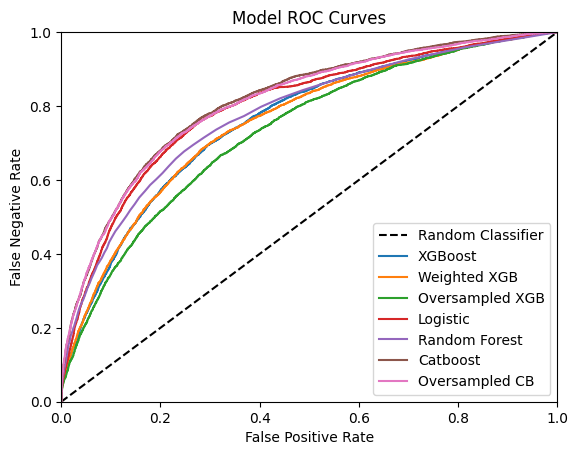

In [97]:
plot_roc_curve({
    "XGBoost": xgb_model,
    "Weighted XGB": w_xgb_model,
    "Oversampled XGB": os_xgb_model,
    "Logistic": logistic_model,
    "Random Forest": rf_model,
    "Catboost": cb_model,
    "Oversampled CB": os_cb_model
    }, X_test, y_test)
plt.show()

### Comparison Table

In [101]:
metrics_df = pd.DataFrame([
    xgb_metrics,
    w_xgb_metrics,
    os_xgb_metrics,
    cb_metrics,
    os_cb_metrics,
    rf_metrics,
    logistic_metrics
])
metrics_df.index = [
    "XGBoost",
    "Weighted XGB",
    "Oversampled XGB",
    "Catboost",
    "Oversampled CB",
    "Random Forest",
    "Logistic"
]
metrics_df

,Recall,Precision,F1,Accuracy,AUC,MCC,Brier,LogLoss,BalancedAccuracy,ROC AUC
XGBoost,0.245929,0.397292,0.303801,0.859232,0.757333,0.238508,0.108041,0.423263,0.596343,NaN
Weighted XGB,0.425527,0.336107,0.375568,0.823285,0.755153,0.276885,0.134216,0.501004,0.652788,NaN
Oversampled XGB,0.554837,0.255458,0.349841,0.742449,0.731300,0.240960,0.179391,0.582878,0.662030,NaN
Catboost,0.170498,0.631206,0.268477,0.883964,NaN,0.286166,0.088186,0.298486,0.578141,0.811579
Oversampled CB,0.718630,0.301638,0.424920,0.757073,NaN,0.347957,0.166491,0.502819,0.740595,0.807699
Random Forest,0.191810,0.546012,0.283892,0.879149,NaN,0.272870,0.094177,0.487484,0.584525,0.775089
Logistic,0.731561,0.290869,0.416241,0.743735,NaN,0.339762,0.182453,0.550120,0.738517,0.795456


### Predictions

In [130]:
import numpy as np
import rocketxg.plotting as rplot
from rocketxg.shots.shot_analysis import distance_to_goal_center, goal_angle

In [136]:
def _dist_to_goal(x, y):
    return distance_to_goal_center([x, y, 0], False)
v_dist_to_goal = np.vectorize(_dist_to_goal)

def _goal_angle(x, y):
    return goal_angle([x, y], False)
v_goal_angle = np.vectorize(_goal_angle)

In [137]:
xcoords = np.linspace(-4096, 4096, 100)
ycoords = np.linspace(-5120, 5120, 100)
Xcoords, Ycoords = np.meshgrid(xcoords, ycoords)

In [240]:
X_plot = pd.DataFrame({
    "goal_angle": v_goal_angle(Xcoords, Ycoords).ravel(),
    "ball_height": np.zeros_like(Xcoords).ravel(),
    "ball_distance": v_dist_to_goal(Xcoords, Ycoords).ravel()
})
plot_proba = logistic_model.predict_proba(X_plot)[:, 1].reshape(Xcoords.shape)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.236253e-16..1.0].


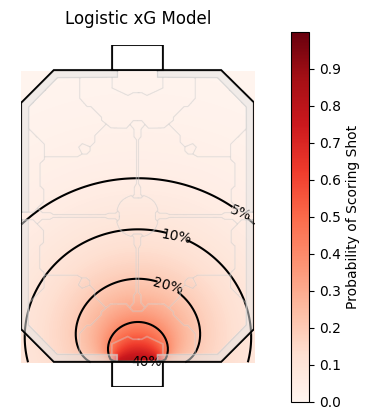

In [243]:
fig, ax = rplot.plot_field()
im = ax.contourf(
    Xcoords, Ycoords, plot_proba,
    cmap="Reds", levels=np.linspace(0, 0.999, 1000)
)
cs = ax.contour(Xcoords, Ycoords, plot_proba, colors="k", levels=[0.05, 0.1, 0.2, 0.4])
ax.clabel(cs, cs.levels, fontsize=10, fmt = lambda x: f"{100*x:.0f}%")

ax.set_title("Logistic xG Model")
cb = fig.colorbar(im)
cb.set_label("Probability of Scoring Shot")
ax.set_axis_off()
plt.show()